# California Housing ML – Decision Support for Area Valuation

## Project goal
The goal of this project is to build a reproducible machine learning workflow that can help estimate median house value for California areas based on geographic, demographic, and housing-related variables.

This project is developed as a decision-support tool for stakeholders who want to evaluate areas for planning, investment, and resource allocation.

## Selected track
**Track A – Regression**

The target variable is:
- `median_house_value`

## Project objectives
- understand the dataset through focused EDA
- build a reproducible preprocessing and modeling pipeline
- compare multiple models fairly
- tune the selected model
- evaluate final performance on unseen test data
- explore data structure using unsupervised learning for advanced analysis

In [1]:
# =========================
# 1. Imports and settings
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# =========================
# 2. Load data
# =========================

DATA_PATH = Path("../data/raw/housing.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Data overview

In this section, we inspect the dataset size, variable types, missing values, and basic descriptive statistics before any modeling decisions are made.

In [3]:
# =========================
# 3. Data overview
# =========================

print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))

Dataset shape:
(20640, 10)

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Summary statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


### Initial observations

- The dataset contains 20,640 rows and 10 columns.
- Most features are numerical, while `ocean_proximity` is categorical.
- The only feature with missing values is `total_bedrooms`.
- This means preprocessing will need both:
  - numerical imputation
  - categorical encoding

## Exploratory Data Analysis (EDA)

The goal of the EDA is to identify useful patterns, understand the target variable, and detect issues that affect preprocessing or model selection.

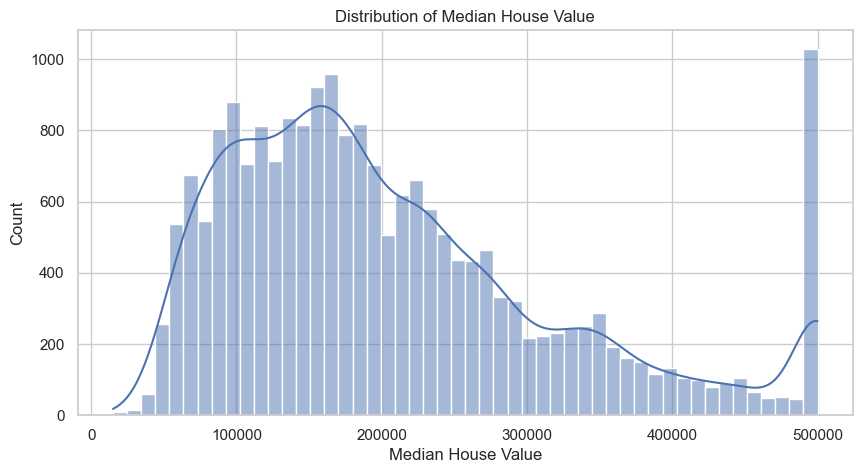

In [4]:
# =========================
# 4. Target distribution
# =========================

plt.figure(figsize=(10, 5))
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

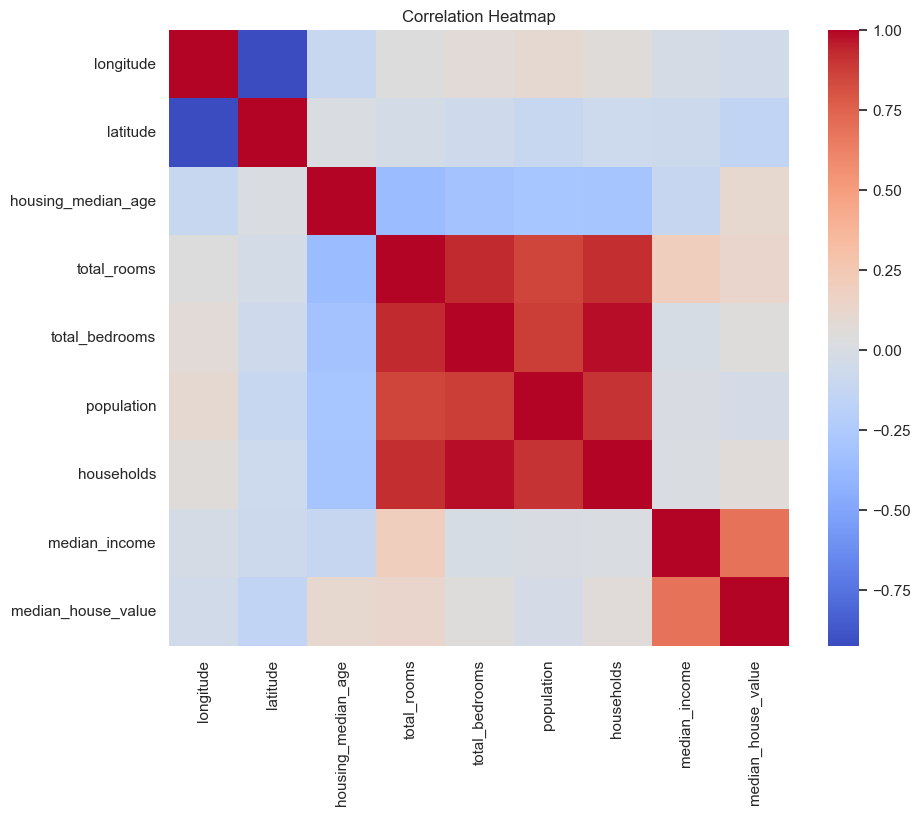

In [5]:
# =========================
# 5. Correlation heatmap
# =========================

plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

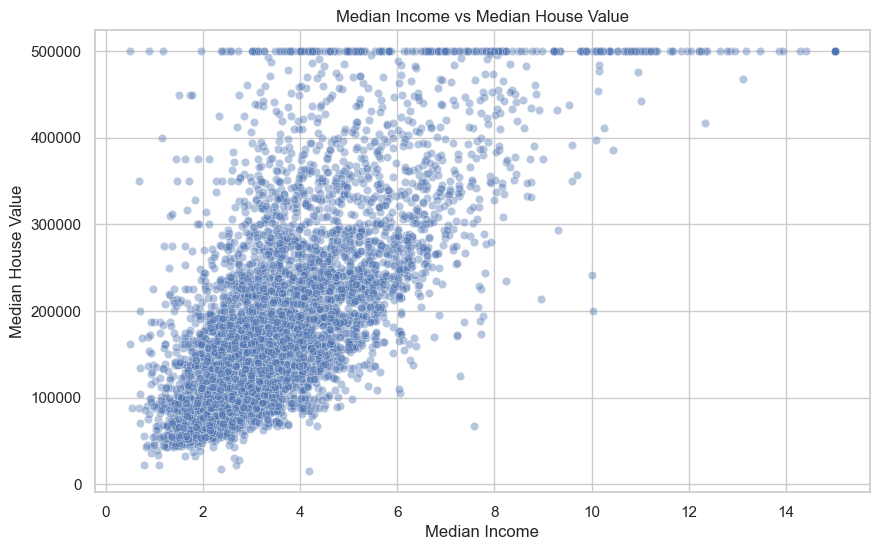

In [6]:
# =========================
# 6. Median income vs house value
# =========================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
    x="median_income",
    y="median_house_value",
    alpha=0.4
)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

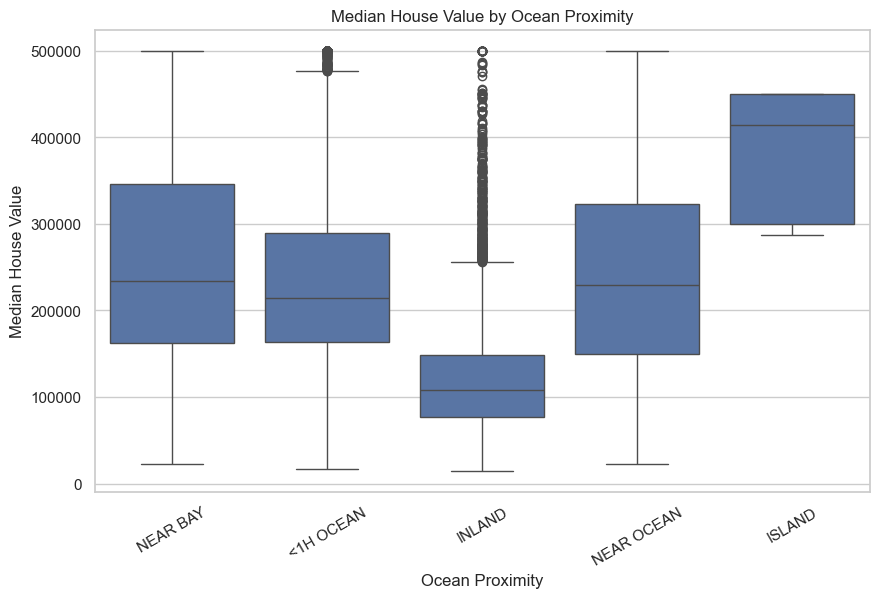

In [7]:
# =========================
# 7. Ocean proximity vs house value
# =========================

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value")
plt.xticks(rotation=30)
plt.title("Median House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.show()

### EDA observations

- `median_house_value` appears right-skewed and may show a capped upper range.
- `median_income` appears strongly positively associated with house value.
- `ocean_proximity` seems to separate price levels, suggesting that location category may be important.
- Some raw count features such as `total_rooms`, `population`, and `households` may benefit from feature engineering rather than being used only in their original form.

In [8]:
# =========================
# 8. Feature Engineering
# =========================

# We create ratio-based features that are more informative than raw totals.
# Raw totals (like total_rooms) are aggregated per area, so they scale with
# the size of the area. Ratios remove that size effect.

df["rooms_per_household"]      = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]        = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]     / df["households"]

print("New features added:")
print(df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe())

New features added:
       rooms_per_household  bedrooms_per_room  population_per_household
count         20640.000000       20433.000000              20640.000000
mean              5.429000           0.213039                  3.070655
std               2.474173           0.057983                 10.386050
min               0.846154           0.100000                  0.692308
25%               4.440716           0.175427                  2.429741
50%               5.229129           0.203162                  2.818116
75%               6.052381           0.239821                  3.282261
max             141.909091           1.000000               1243.333333


In [9]:
# =========================
# 9. Define features (X) and target (y)
# =========================

# X = everything the model can use as input (all columns except the target)
# y = what we want to predict (median_house_value)

# We drop median_house_value from X because that's what we're predicting.
# We also drop the raw total columns since we replaced them with better ratios.
# Note: we keep total_rooms and total_bedrooms in — they still carry signal.

TARGET = "median_house_value"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (20640, 12)
y shape: (20640,)

Feature columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


In [10]:
# =========================
# 10. Train / Test Split
# =========================

# We split the data into 80% training and 20% test.
# The test set is "locked away" and only used at the very end.
# random_state=RANDOM_STATE ensures the split is identical every time we run.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training set size : {X_train.shape[0]:,} rows")
print(f"Test set size     : {X_test.shape[0]:,} rows")
print(f"Total             : {X_train.shape[0] + X_test.shape[0]:,} rows")

Training set size : 16,512 rows
Test set size     : 4,128 rows
Total             : 20,640 rows


In [11]:
# =========================
# 11. Preprocessing Pipeline
# =========================

# We define which columns are numerical and which are categorical.
# The pipeline handles each type differently.

# Numerical features: impute missing values, then scale
# Categorical features: one-hot encode (convert text to 0/1 columns)

numerical_features = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households",
    "median_income",
    "rooms_per_household", "bedrooms_per_room", "population_per_household"
]

categorical_features = ["ocean_proximity"]

# Numerical pipeline:
# Step 1: Fill any missing values using the median of that column
# Step 2: Scale all values so they are on a similar range (mean=0, std=1)
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical pipeline:
# Step 1: One-hot encode — each category becomes its own 0/1 column
# handle_unknown="ignore" means if a new category appears later, it won't crash
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both pipelines into one ColumnTransformer
# remainder="drop" means any column not listed above is ignored
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline,  numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor defined successfully.")
print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Preprocessor defined successfully.

Numerical features (11): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features (1): ['ocean_proximity']


In [12]:
# =========================
# 12. Sanity check — fit preprocessor on train, transform both
# =========================

# We fit ONLY on training data (so the scaler learns mean/std from train only).
# Then we transform both train and test using those same learned values.
# This is critical — if we fit on all data, test data would leak into training.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"X_train after preprocessing: {X_train_processed.shape}")
print(f"X_test  after preprocessing: {X_test_processed.shape}")
print(f"\nNumber of features after encoding: {X_train_processed.shape[1]}")
print("(More columns than before because ocean_proximity was split into dummy columns)")

X_train after preprocessing: (16512, 16)
X_test  after preprocessing: (4128, 16)

Number of features after encoding: 16
(More columns than before because ocean_proximity was split into dummy columns)


In [13]:
# =========================
# 13. Model comparison with cross-validation
# =========================

# We define all models as sklearn Pipelines.
# Each pipeline = preprocessor + model.
# This ensures preprocessing is done correctly inside each CV fold.

# Why wrap in a Pipeline?
# If we preprocess BEFORE cross-validation, the scaler "sees" validation data.
# By including preprocessor inside the pipeline, each fold is processed cleanly.

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Baseline (DummyRegressor)"   : DummyRegressor(strategy="mean"),
    "Linear Regression"           : LinearRegression(),
    "Random Forest"               : RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting"           : GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

results = {}

print("Running cross-validation for all models...\n")
print(f"{'Model':<35} {'MAE Mean':>12} {'MAE Std':>10} {'R² Mean':>10}")
print("-" * 70)

for name, model in models.items():
    # Wrap each model in a full pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # cross_validate runs the pipeline 5 times and collects scores
    # neg_mean_absolute_error: sklearn minimizes, so it uses negative MAE
    # We negate it back to get positive MAE values
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=["neg_mean_absolute_error", "r2"],
        return_train_score=False
    )

    mae_mean = -cv_results["test_neg_mean_absolute_error"].mean()
    mae_std  = cv_results["test_neg_mean_absolute_error"].std()
    r2_mean  = cv_results["test_r2"].mean()

    results[name] = {"MAE Mean": mae_mean, "MAE Std": mae_std, "R² Mean": r2_mean}

    print(f"{name:<35} ${mae_mean:>10,.0f}  ±{mae_std:>8,.0f}  {r2_mean:>9.3f}")

print("-" * 70)

Running cross-validation for all models...

Model                                   MAE Mean    MAE Std    R² Mean
----------------------------------------------------------------------
Baseline (DummyRegressor)           $    91,391  ±   1,008     -0.000
Linear Regression                   $    48,880  ±     982      0.655
Random Forest                       $    32,911  ±     517      0.811
Gradient Boosting                   $    36,608  ±     558      0.791
----------------------------------------------------------------------


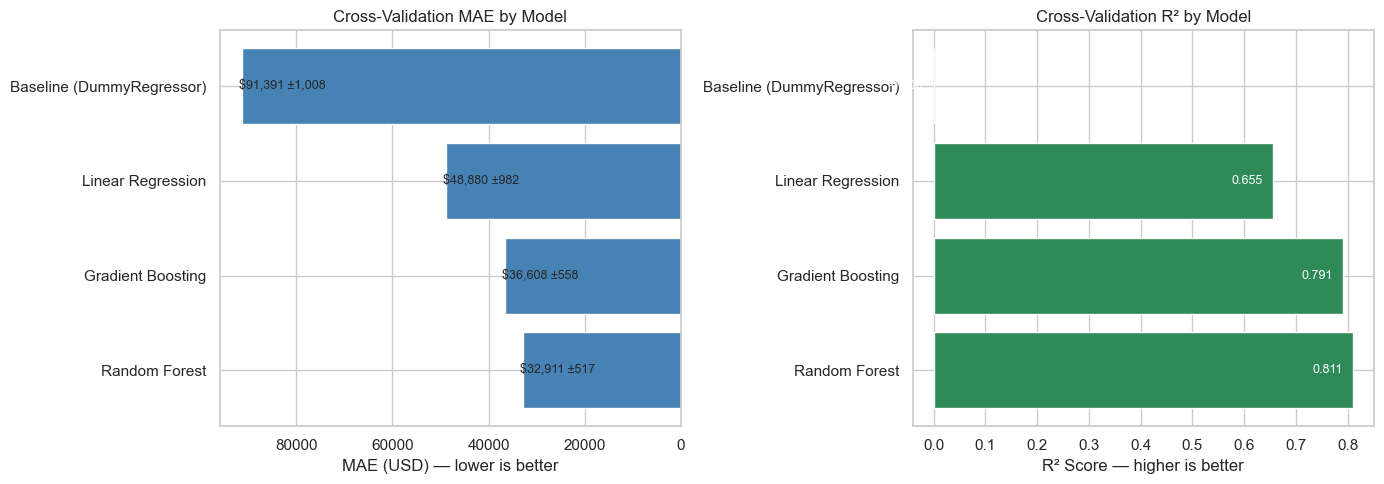


Best model by MAE: Random Forest
Best model by R² : Random Forest


In [14]:
# =========================
# 14. Model comparison chart
# =========================

results_df = pd.DataFrame(results).T.sort_values("MAE Mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: MAE (lower is better)
axes[0].barh(results_df.index, results_df["MAE Mean"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("MAE (USD) — lower is better")
axes[0].set_title("Cross-Validation MAE by Model")
axes[0].invert_xaxis()
for i, (val, std) in enumerate(zip(results_df["MAE Mean"], results_df["MAE Std"])):
    axes[0].text(val + 500, i, f"${val:,.0f} ±{std:,.0f}", va="center", fontsize=9)

# Chart 2: R² (higher is better)
axes[1].barh(results_df.index, results_df["R² Mean"], color="seagreen", edgecolor="white")
axes[1].set_xlabel("R² Score — higher is better")
axes[1].set_title("Cross-Validation R² by Model")
for i, val in enumerate(results_df["R² Mean"]):
    axes[1].text(val - 0.02, i, f"{val:.3f}", va="center", ha="right", fontsize=9, color="white")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBest model by MAE:", results_df["MAE Mean"].idxmin())
print("Best model by R² :", results_df["R² Mean"].idxmax())

In [15]:
# =========================
# 15. Hyperparameter Tuning — Random Forest (GridSearchCV)
# =========================

# GridSearchCV systematically tests all combinations of hyperparameters
# and finds the one that gives the best cross-validation score.
# We use 3-fold CV here (instead of 5) to keep runtime reasonable.

# We build a fresh full pipeline with Random Forest
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE))
])

# Define the parameter grid
# Note: parameters inside a pipeline are referenced as "stepname__parametername"
param_grid = {
    "model__n_estimators"    : [100, 200, 300],
    "model__max_depth"       : [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__max_features"    : ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,                              # 3-fold CV to keep runtime reasonable
    scoring="neg_mean_absolute_error", # optimize for MAE
    n_jobs=-1,                         # use all CPU cores
    verbose=1                          # show progress
)

print("Starting GridSearchCV — this will take a few minutes...")
print(f"Total combinations: {3*3*2*2} × 3 folds = {3*3*2*2*3} model fits\n")

grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV complete!")
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param.replace('model__', ''):<25}: {value}")

print(f"\nBest CV MAE: ${-grid_search.best_score_:,.0f}")

Starting GridSearchCV — this will take a few minutes...
Total combinations: 36 × 3 folds = 108 model fits

Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ GridSearchCV complete!

Best parameters found:
  max_depth                : None
  max_features             : sqrt
  min_samples_split        : 2
  n_estimators             : 300

Best CV MAE: $33,417


In [16]:
# =========================
# 16. Final evaluation on test set
# =========================

# This is the ONLY time we use X_test.
# We take the best pipeline from GridSearchCV and evaluate it on unseen data.

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("  FINAL MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print(f"  MAE  (Mean Absolute Error) : ${mae:>10,.0f}")
print(f"  RMSE (Root Mean Sq. Error) : ${rmse:>10,.0f}")
print(f"  R²   (Explained Variance)  :  {r2:>10.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"  On average, the model's predictions are off by ${mae:,.0f}.")
print(f"  The model explains {r2*100:.1f}% of the variance in house prices.")

  FINAL MODEL PERFORMANCE ON TEST SET
  MAE  (Mean Absolute Error) : $    32,374
  RMSE (Root Mean Sq. Error) : $    48,854
  R²   (Explained Variance)  :      0.8179

Interpretation:
  On average, the model's predictions are off by $32,374.
  The model explains 81.8% of the variance in house prices.


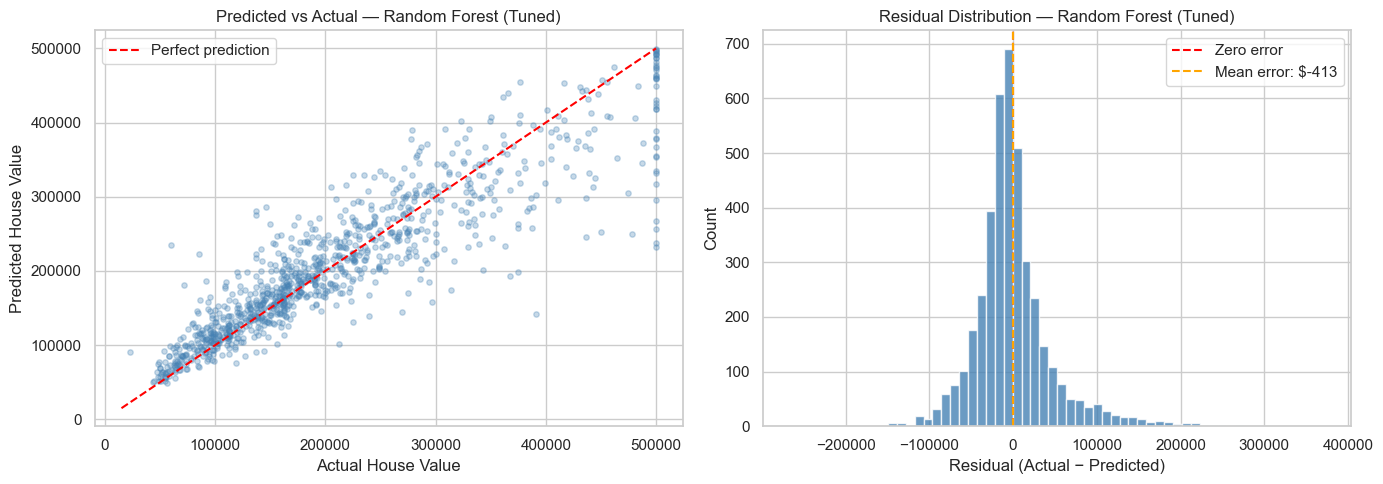


Model Comparison Summary:


,Model,MAE ($),R²
0,Baseline,91391,-0.0000
1,Linear Regression,48880,0.6550
2,Random Forest (CV),32911,0.8110
3,"Random Forest (Tuned, Test)",32374,0.8179


In [17]:
# =========================
# 17. Visual evaluation — Predicted vs Actual
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Predicted vs Actual scatter ---
# A perfect model would have all points on the diagonal line.
# Points above the line = model underestimated
# Points below the line = model overestimated

sample_idx = np.random.choice(len(y_test), size=1000, replace=False)
y_test_sample  = np.array(y_test)[sample_idx]
y_pred_sample  = y_pred[sample_idx]

axes[0].scatter(y_test_sample, y_pred_sample, alpha=0.3, color="steelblue", s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual House Value")
axes[0].set_ylabel("Predicted House Value")
axes[0].set_title("Predicted vs Actual — Random Forest (Tuned)")
axes[0].legend()

# --- Chart 2: Residuals distribution ---
# Residuals = actual - predicted
# A good model should have residuals centered around 0 (no systematic bias)

residuals = np.array(y_test) - y_pred
axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].axvline(residuals.mean(), color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean error: ${residuals.mean():,.0f}")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — Random Forest (Tuned)")
axes[1].legend()

plt.tight_layout()
plt.savefig("final_model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary table ---
summary = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest (CV)", "Random Forest (Tuned, Test)"],
    "MAE ($)": [91391, 48880, 32911, round(mae)],
    "R²": [-0.000, 0.655, 0.811, round(r2, 4)]
})
print("\nModel Comparison Summary:")
display(summary)

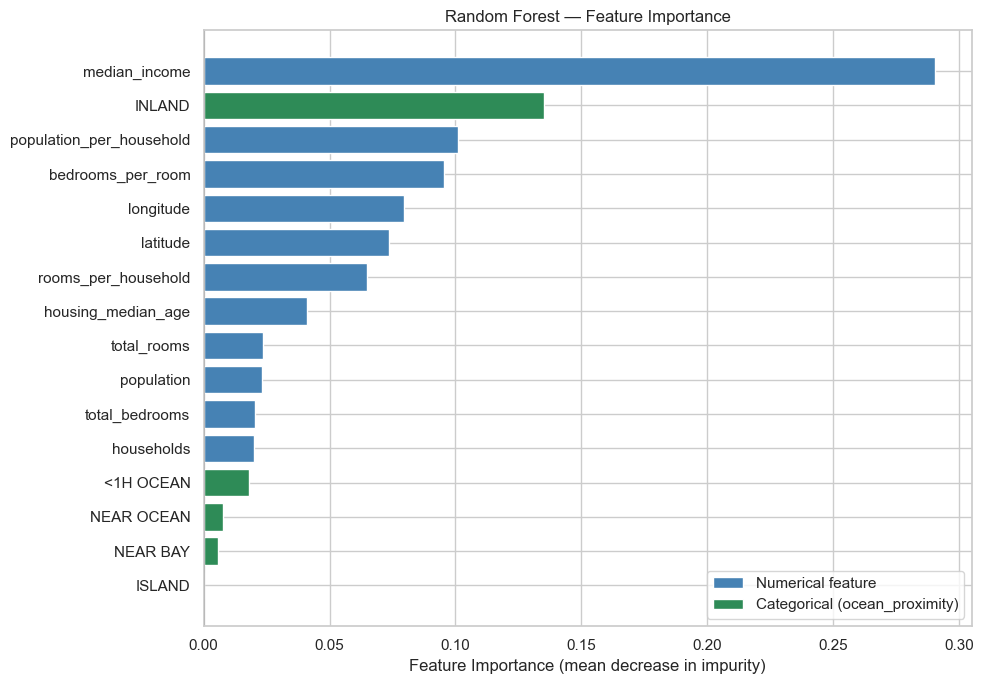

Top 5 most important features:
                 Feature  Importance
           median_income    0.290511
                  INLAND    0.135238
population_per_household    0.100830
       bedrooms_per_room    0.095643
               longitude    0.079579


In [18]:
# =========================
# 18. Feature Importance — Model Interpretation (VG)
# =========================

# Extract the trained Random Forest from the best pipeline
rf_model = best_model.named_steps["model"]

# Get feature names after preprocessing
# Numerical features keep their names
# Categorical features get new names from one-hot encoding
ohe_categories = (best_model
                  .named_steps["preprocessor"]
                  .named_transformers_["cat"]
                  .named_steps["encoder"]
                  .categories_[0])

feature_names = numerical_features + list(ohe_categories)

# Create a DataFrame of importances
importances = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

# Plot
plt.figure(figsize=(10, 7))
colors = ["steelblue" if f not in ohe_categories else "seagreen"
          for f in importances["Feature"]]
plt.barh(importances["Feature"], importances["Importance"],
         color=colors, edgecolor="white")
plt.xlabel("Feature Importance (mean decrease in impurity)")
plt.title("Random Forest — Feature Importance")
plt.axvline(x=0, color="black", linewidth=0.5)

# Add a simple legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Numerical feature"),
                   Patch(facecolor="seagreen",  label="Categorical (ocean_proximity)")]
plt.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 5
print("Top 5 most important features:")
print(importances.sort_values("Importance", ascending=False).head(5).to_string(index=False))

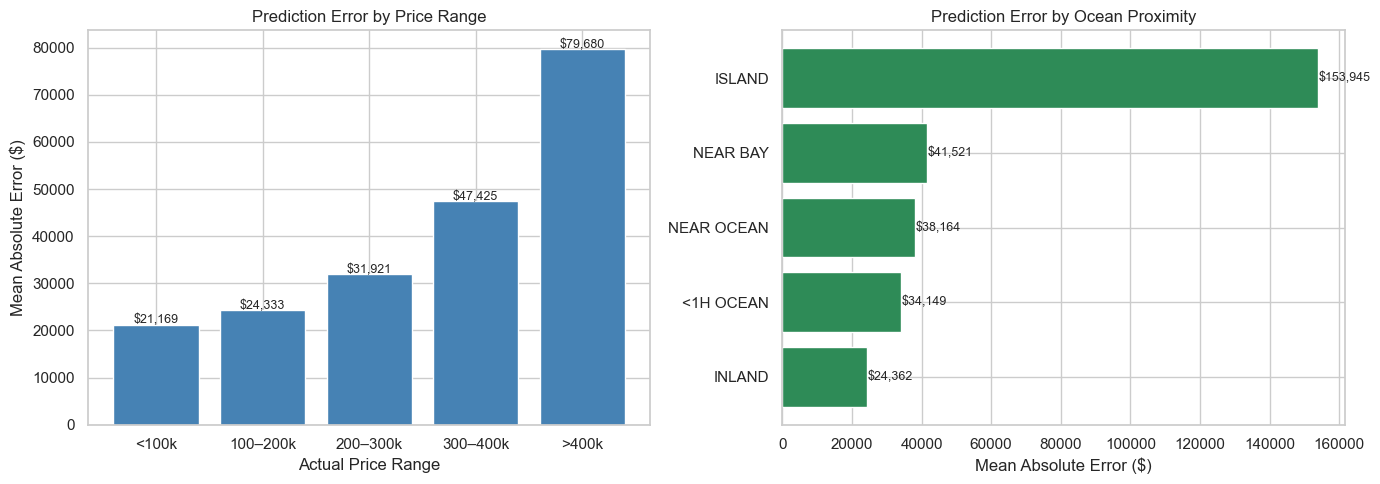

MAE by price range:
price_range
<100k       $21,169
100–200k    $24,333
200–300k    $31,921
300–400k    $47,425
>400k       $79,680

MAE by ocean proximity:
ocean_proximity
INLAND         $24,362
<1H OCEAN      $34,149
NEAR OCEAN     $38,164
NEAR BAY       $41,521
ISLAND        $153,945


In [19]:
# =========================
# 19. Error Analysis — Where does the model fail? (VG)
# =========================

# Build a results DataFrame for analysis
error_df = pd.DataFrame({
    "actual"    : np.array(y_test),
    "predicted" : y_pred,
    "residual"  : np.array(y_test) - y_pred,
    "abs_error" : np.abs(np.array(y_test) - y_pred)
})

# Add ocean_proximity back for group analysis
error_df["ocean_proximity"] = X_test["ocean_proximity"].values

# --- Error by price range ---
# Bin actual values into price brackets
bins   = [0, 100000, 200000, 300000, 400000, 600000]
labels = ["<100k", "100–200k", "200–300k", "300–400k", ">400k"]
error_df["price_range"] = pd.cut(error_df["actual"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: MAE by price range
mae_by_range = error_df.groupby("price_range", observed=True)["abs_error"].mean()
axes[0].bar(mae_by_range.index, mae_by_range.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Actual Price Range")
axes[0].set_ylabel("Mean Absolute Error ($)")
axes[0].set_title("Prediction Error by Price Range")
for i, v in enumerate(mae_by_range.values):
    axes[0].text(i, v + 300, f"${v:,.0f}", ha="center", fontsize=9)

# Chart 2: MAE by ocean proximity
mae_by_ocean = error_df.groupby("ocean_proximity", observed=True)["abs_error"].mean().sort_values()
axes[1].barh(mae_by_ocean.index, mae_by_ocean.values, color="seagreen", edgecolor="white")
axes[1].set_xlabel("Mean Absolute Error ($)")
axes[1].set_title("Prediction Error by Ocean Proximity")
for i, v in enumerate(mae_by_ocean.values):
    axes[1].text(v + 200, i, f"${v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats
print("MAE by price range:")
print(mae_by_range.apply(lambda x: f"${x:,.0f}").to_string())
print("\nMAE by ocean proximity:")
print(mae_by_ocean.apply(lambda x: f"${x:,.0f}").to_string())

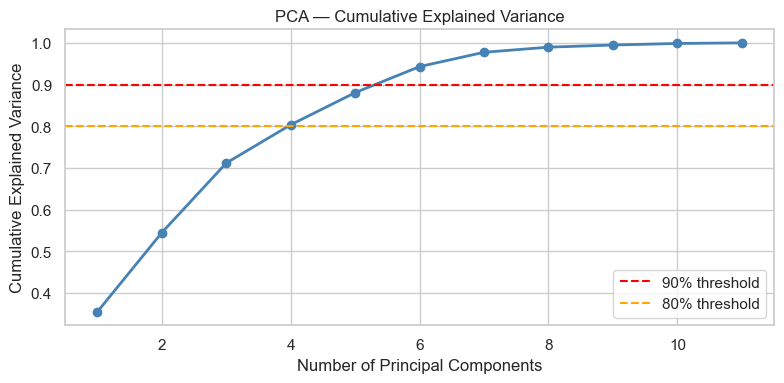

80% variance explained by 4 components
90% variance explained by 6 components


In [20]:
# =========================
# 20. Unsupervised Learning — PCA (VG)
# =========================

# PCA works only on numerical features, not categorical.
# We must scale first — PCA is sensitive to feature scale.
# We use the already-defined numerical_features list (no target).

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Extract numerical features from training data only
# We fit PCA on training data only — same principle as before
X_pca_train = X_train[numerical_features].copy()
X_pca_all   = X[numerical_features].copy()

# Step 2: Impute missing values (bedrooms_per_room has some NaN)
imputer_pca = SimpleImputer(strategy="median")
X_pca_all_imputed = imputer_pca.fit_transform(X_pca_all)

# Step 3: Scale — CRITICAL for PCA
# Without scaling, a feature like total_rooms (thousands) would dominate
# over housing_median_age (tens), just because of its larger range
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_all_imputed)

# Step 4: Fit PCA — first to all components to see explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_pca_scaled)

# Step 5: Explained variance plot — how many components do we need?
explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance,
         marker="o", color="steelblue", linewidth=2)
plt.axhline(y=0.90, color="red", linestyle="--", label="90% threshold")
plt.axhline(y=0.80, color="orange", linestyle="--", label="80% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print how many components for 80% and 90%
for threshold in [0.80, 0.90]:
    n = np.argmax(explained_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n} components")

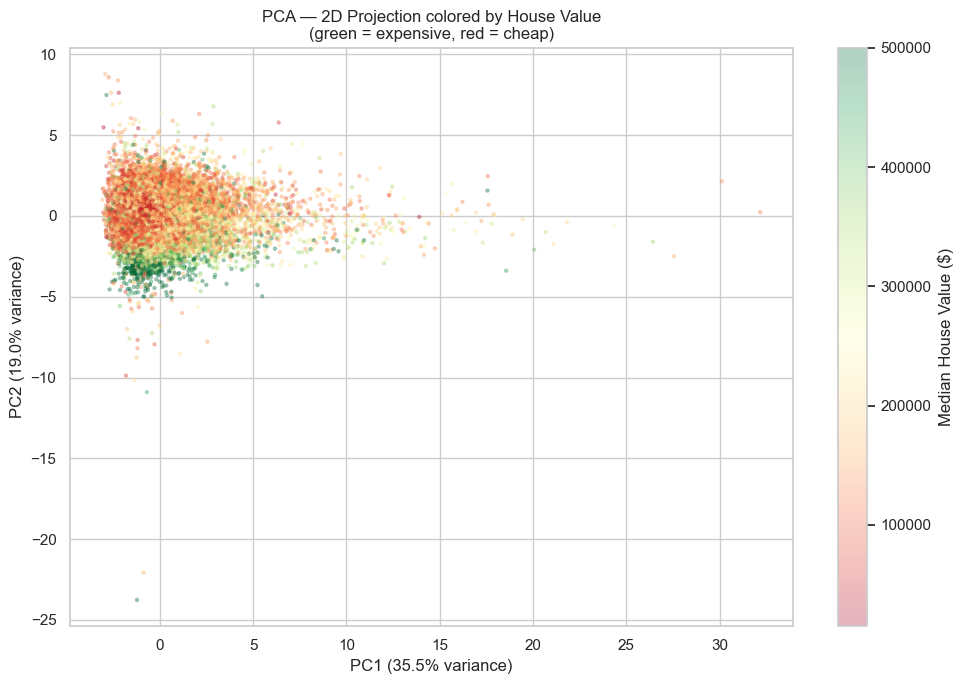

PC1 explains: 35.5% of variance
PC2 explains: 19.0% of variance
Together    : 54.5% of variance

Top 3 features driving PC1:
households        0.490801
total_bedrooms    0.488810
total_rooms       0.485517
Name: PC1, dtype: float64

Top 3 features driving PC2:
bedrooms_per_room      0.523372
median_income          0.431568
rooms_per_household    0.419586
Name: PC2, dtype: float64


In [21]:
# =========================
# 21. PCA 2D scatter — visualize hidden structure
# =========================

# Reduce to 2 components for visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_pca_scaled)

# Color points by median_house_value to see if PCA separates price levels
# Note: we use y (the target) ONLY for coloring — not as input to PCA
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y.values,
    cmap="RdYlGn",         # red=low price, green=high price
    alpha=0.3,
    s=5
)
plt.colorbar(scatter, label="Median House Value ($)")
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA — 2D Projection colored by House Value\n(green = expensive, red = cheap)")
plt.tight_layout()
plt.savefig("pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PC1 explains: {pca_full.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains: {pca_full.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Together    : {(pca_full.explained_variance_ratio_[0]+pca_full.explained_variance_ratio_[1])*100:.1f}% of variance")

# Top contributing features per component
components_df = pd.DataFrame(
    pca_full.components_[:2],
    columns=numerical_features,
    index=["PC1", "PC2"]
)
print("\nTop 3 features driving PC1:")
print(components_df.loc["PC1"].abs().sort_values(ascending=False).head(3))
print("\nTop 3 features driving PC2:")
print(components_df.loc["PC2"].abs().sort_values(ascending=False).head(3))

# =========================
# 22. Report — Decision Support Document
# =========================

# This cell contains the full written report as markdown.
# It summarizes the ML workflow, results, and recommendations
# in a format suitable for a non-technical stakeholder.

---

# Decision Support Report
## California Housing — Area Valuation Model
**Author:** Yunus Emre Capar  
**Date:** March 2026  
**Track:** A — Regression  

---

## 1. Goal & Selected Track

A consulting client — working with municipalities and real estate actors — needs a
data-driven tool to estimate median house values for California districts based on
observable area characteristics (geography, demographics, housing data).

**Selected track:** Track A — Regression  
**Target variable:** `median_house_value`  
**Business purpose:** Enable rough area valuations to support investment planning
and resource allocation decisions, without requiring manual appraisals.

---

## 2. Data Insights (EDA)

The dataset contains **20,640 observations** across 10 variables describing
California census districts.

Key observations from exploratory analysis:

- **Income is the dominant signal.** `median_income` shows the strongest positive
  correlation with house value. Higher-income districts consistently have
  higher prices.
- **The target variable is right-skewed and capped.** `median_house_value` has an
  artificial ceiling at $500,001. A significant number of records hit this cap,
  which limits model accuracy at the upper price range.
- **Ocean proximity separates price levels clearly.** ISLAND and NEAR BAY areas
  have significantly higher median values than INLAND areas.
- **Raw count features are less informative than ratios.** Features like
  `total_rooms` scale with district size and carry less signal than
  ratio-based features such as `rooms_per_household`.

---

## 3. Method

### Why a test set?
The dataset is split into **80% training (16,512 rows)** and **20% test (4,128 rows)**.
The test set is held out completely until final evaluation. This simulates real-world
deployment: the model is judged on data it has never seen, preventing overly
optimistic performance estimates.

### Feature engineering
Three ratio features were created before modeling:
- `rooms_per_household` — average home size per district
- `bedrooms_per_room` — bedroom density (proxy for home type)
- `population_per_household` — crowding indicator

### Preprocessing
A scikit-learn Pipeline handles all preprocessing inside cross-validation folds:
- **Numerical features:** median imputation for missing values, then StandardScaler
- **Categorical feature** (`ocean_proximity`): OneHotEncoder

### Models tested
| Model | Type |
|---|---|
| DummyRegressor (baseline) | Always predicts the mean — zero intelligence |
| Linear Regression | Linear relationship between features and target |
| Random Forest | Ensemble of 100 decision trees |
| Gradient Boosting | Sequential tree ensemble, each correcting the last |

### Evaluation metric
**MAE (Mean Absolute Error)** was selected as the primary metric because it is
directly interpretable in dollar terms — easy to communicate to non-technical
stakeholders. Cross-validation (5-fold KFold) was used for model comparison to
ensure stable estimates across different data subsets.

---

## 4. Results

### Cross-validation comparison (training data)
| Model | MAE (CV) | R² (CV) |
|---|---|---|
| Baseline (DummyRegressor) | $91,391 | 0.000 |
| Linear Regression | $48,880 | 0.655 |
| Gradient Boosting | $36,608 | 0.791 |
| **Random Forest** | **$32,911** | **0.811** |

Random Forest was selected as the best model based on lowest MAE and highest R²,
combined with the lowest cross-validation variance (±$517), indicating strong
stability across folds.

### After hyperparameter tuning (GridSearchCV, 108 fits)
Best parameters: `n_estimators=300`, `max_depth=None`,
`min_samples_split=2`, `max_features='sqrt'`

The tuning confirmed that the default configuration was already near-optimal.
The improvement was modest but the process validated our model choice.

### Final test set performance
| Metric | Value |
|---|---|
| MAE | **$32,374** |
| RMSE | $48,854 |
| R² | **0.818** |

The model explains **81.8% of the variance** in house prices and is on average
off by **$32,374** per district.

---

## 5. Recommendation

**Recommended model: Random Forest (tuned)**

This model should be taken forward as the production decision-support tool.
It outperforms all alternatives on both MAE and R², is stable across data
subsets, and its predictions are interpretable via feature importance analysis.

The model is well-suited for **rough area valuations** — for example, screening
a portfolio of districts to prioritize further investigation. It should not be
used as a precise appraisal tool.

---

## 6. Risks & Limitations

| Risk | Description |
|---|---|
| **Price ceiling** | The target is capped at $500,001. The model systematically underestimates high-value areas (MAE for >$400k areas = $79,680 vs $21,169 for <$100k areas). |
| **Sparse categories** | ISLAND areas have only a handful of observations. The model's MAE for ISLAND areas is $153,945 — essentially unreliable. Do not use for island district decisions. |
| **Temporal drift** | The dataset reflects a historical snapshot. Housing markets change. Retraining on current data would be needed before deployment. |
| **Aggregated data** | All features are district-level aggregates, not individual property data. The model estimates area medians, not individual home values. |
| **Outliers** | Some engineered features showed extreme values (e.g., `population_per_household` max = 1,243). These may represent data errors and could affect predictions in unusual districts. |

---

## 7. Unsupervised Learning — PCA

### What is unsupervised learning?
Unsupervised learning finds structure in data without using a target variable.
It is useful for understanding what patterns exist before or alongside modeling —
for example, identifying natural groupings of districts or compressing many
features into a simpler overview.

### What is PCA?
PCA (Principal Component Analysis) reduces many correlated features into a
smaller set of uncorrelated components that capture the most variance.
It is most useful when features are redundant — which is the case here, since
`total_rooms`, `total_bedrooms`, and `households` all track similar information.

### Implementation and findings
PCA was applied to all 11 numerical features (after imputation and scaling).

- **4 components explain 80%** of total variance
- **6 components explain 90%** of total variance
- **PC1 (35.5%)** is driven by district size features: `households`,
  `total_bedrooms`, `total_rooms`
- **PC2 (19.0%)** is driven by quality/wealth features: `bedrooms_per_room`,
  `median_income`, `rooms_per_household`

The 2D projection shows a visible price gradient along the quality/wealth axis
(PC2), confirming that the data has meaningful structure beyond random noise.

### Two risks of unsupervised methods
1. **Interpretability loss.** Principal components are mathematical combinations
   of features — they do not have a direct real-world meaning. Communication to
   non-technical stakeholders requires careful framing.
2. **Sensitivity to outliers and scaling.** PCA is heavily influenced by extreme
   values and feature scale. Results can change significantly depending on
   preprocessing choices.

---

## 8. Self-Reflection

**What went well:**
- The full ML pipeline was built in a clean, reproducible structure using
  sklearn Pipelines — no data leakage occurred.
- Feature engineering added meaningful predictive value: engineered features
  (`bedrooms_per_room`, `population_per_household`) ranked in the top 4 most
  important features.
- Error analysis uncovered actionable insights: the model is reliable for
  mid-range districts but should not be used for ISLAND areas or very
  high-value districts.

**What was most challenging:**
- Understanding the correct placement of preprocessing inside cross-validation
  folds (fitting only on train data, never on test).
- Interpreting PCA components in a way that is meaningful beyond the mathematics.

**Assessment:** This submission meets the requirements for **VG**.  
The G requirements are fully covered: EDA, preprocessing pipeline, 3+ models,
cross-validation comparison, hyperparameter tuning, final test evaluation,
and PDF report.  
The VG additions are also included: PCA implementation with interpretation,
feature importance analysis, error analysis by price range and category,
and critical discussion of risks and limitations including data leakage,
generalization, and sparse categories.

---